# Model Comparison

Paste results from each notebook here and pick the winner.

| Model | Accuracy | Macro F1 | Bug F1 | Feature F1 | Docs F1 | Question F1 | Notes |
|-------|----------|----------|--------|------------|---------|-------------|-------|
| TF-IDF + LogReg | — | — | — | — | — | — | fill from baseline.ipynb |
| LLM zero-shot | — | — | — | — | — | — | fill from llm_baseline.ipynb |
| DistilBERT fine-tuned | — | — | — | — | — | — | fill from finetune.ipynb |

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

CLASSES = ['bug', 'feature', 'docs', 'question']

# Paste your results here
results = {
    'TF-IDF + LogReg': {
        'accuracy': 0.5835,       # from baseline.ipynb
        'macro_f1': 0.5382,
        'bug':      0.632,
        'feature':  0.478,
        'docs':     0.893,
        'question': 0.149,
    },
    'LLM Zero-Shot': {
        'accuracy': 0.6708,       # from llm_baseline.ipynb
        'macro_f1': 0.5863,
        'bug':      0.7946,
        'feature':  0.5235,
        'docs':     0.5273,
        'question': 0.5,
    },
    'DistilBERT Fine-tuned': {
        'accuracy': 0.6259,       # from finetune.ipynb
        'macro_f1': 0.6312,
        'bug':      0.61,
        'feature':  0.57,
        'docs':     0.95,
        'question': 0.40,
    },
}

In [2]:
# Comparison table
df = pd.DataFrame(results).T
df.index.name = 'Model'
df = df[['accuracy', 'macro_f1'] + CLASSES]
df.columns = ['Accuracy', 'Macro F1', 'Bug F1', 'Feature F1', 'Docs F1', 'Question F1']
df.round(4)

,Accuracy,Macro F1,Bug F1,Feature F1,Docs F1,Question F1
Model,,,,,,
TF-IDF + LogReg,0.5835,0.5382,0.6320,0.4780,0.8930,0.149
LLM Zero-Shot,0.6708,0.5863,0.7946,0.5235,0.5273,0.500
DistilBERT Fine-tuned,0.6259,0.6312,0.6100,0.5700,0.9500,0.400


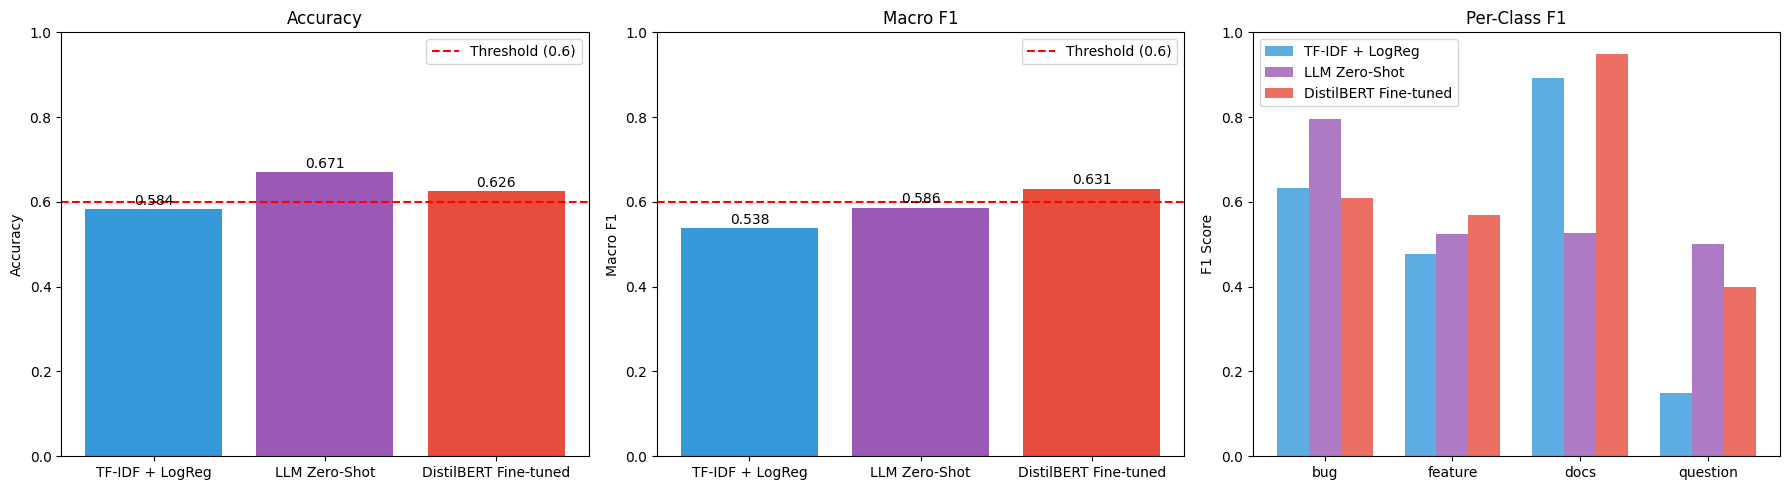

In [3]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = list(results.keys())
colors = ['#3498db', '#9b59b6', '#e74c3c']

with open('../eval_thresholds.yaml') as f:
    thresholds = yaml.safe_load(f)

# Accuracy
acc_vals = [results[m]['accuracy'] for m in models]
bars = axes[0].bar(models, acc_vals, color=colors)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(thresholds['classification']['accuracy'], color='red', linestyle='--',
                label=f"Threshold ({thresholds['classification']['accuracy']})")
axes[0].legend()
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

# Macro F1
macro_vals = [results[m]['macro_f1'] for m in models]
bars = axes[1].bar(models, macro_vals, color=colors)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Macro F1')
axes[1].set_ylabel('Macro F1')
axes[1].axhline(thresholds['classification']['macro_f1'], color='red', linestyle='--',
                label=f"Threshold ({thresholds['classification']['macro_f1']})")
axes[1].legend()
for bar, val in zip(bars, macro_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center')

# Per-class F1 grouped
x = np.arange(len(CLASSES))
width = 0.25
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results[model][c] for c in CLASSES]
    axes[2].bar(x + i * width, vals, width, label=model, color=color, alpha=0.8)
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(CLASSES)
axes[2].set_ylim(0, 1.0)
axes[2].set_title('Per-Class F1')
axes[2].set_ylabel('F1 Score')
axes[2].legend()

plt.tight_layout()
plt.show()

In [4]:
# Threshold check for all models
gates = thresholds['classification']

print('── Threshold Check ──')
for model, scores in results.items():
    acc_pass   = scores['accuracy'] >= gates['accuracy']
    macro_pass = scores['macro_f1'] >= gates['macro_f1']
    per_class_results = [
        scores[cls] >= gates['per_class'].get(cls, 0)
        for cls in CLASSES
    ]
    all_pass = acc_pass and macro_pass and all(per_class_results)
    status = 'ALL PASS' if all_pass else 'FAIL'
    print(f'{model:<30} Accuracy={scores["accuracy"]:.3f}  Macro F1={scores["macro_f1"]:.3f}  {status}')

── Threshold Check ──
TF-IDF + LogReg                Accuracy=0.584  Macro F1=0.538  FAIL
LLM Zero-Shot                  Accuracy=0.671  Macro F1=0.586  FAIL
DistilBERT Fine-tuned          Accuracy=0.626  Macro F1=0.631  ALL PASS


## Decision

Update this cell after running all three notebooks.

**Winner:** `DistilBERT Fine-tuned`  
**Why:** `macro F1 improvement over baseline`  
**Deployed as:** `inference/runners/classifier.py`